In [10]:
import pandas as pd
import numpy as np
import pyodbc
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.min_rows', 40)

sns.set_theme(style='whitegrid', font_scale=1.3)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

DSN = 'Redshift_prod_new'


def run_sql(query, connection=None):
    if connection is None:
        with pyodbc.connect(f'DSN={DSN}') as conn:
            warnings.filterwarnings('ignore', category=UserWarning)
            df = pd.read_sql_query(sql=query, con=conn)
            warnings.filterwarnings('default', category=UserWarning)
            return df
    else:
        warnings.filterwarnings('ignore', category=UserWarning)
        df = pd.read_sql_query(sql=query, con=connection)
        warnings.filterwarnings('default', category=UserWarning)
        return df


print(f'Imports loaded, DSN={DSN}')

Imports loaded, DSN=Redshift_prod_new


In [11]:
query = """
SELECT DATE_TRUNC('month', rec.con_date)                                       AS month,
       AVG(COALESCE(rec.bb_value, cd.blackbook_history_adj_wholesale_amt))      AS avg_bb_value
FROM   sandbox.rds_rec_model_originations rec
       LEFT JOIN edwnpi.los_deal_current_fact cd
              ON rec.account_number = cd.account_number
WHERE  COALESCE(rec.bb_value, cd.blackbook_history_adj_wholesale_amt) > 0
  AND  rec.con_date >= '2020-01-01'
GROUP  BY DATE_TRUNC('month', rec.con_date)
ORDER  BY month
"""

bb_df = run_sql(query)
bb_df['month'] = pd.to_datetime(bb_df['month'])
print(f'Fetched {len(bb_df)} monthly rows')
print(f'Date range: {bb_df["month"].min():%Y-%m} to {bb_df["month"].max():%Y-%m}')
display(bb_df.head())

Fetched 80 monthly rows
Date range: 2020-01 to 2026-08


,month,avg_bb_value
0,2020-01-01,9910.631992
1,2020-02-01,9964.462445
2,2020-03-01,10087.232352
3,2020-04-01,9664.408685
4,2020-05-01,9765.725572


In [12]:
diag_query = """
SELECT CASE WHEN cd.aspect = 'APPLICATION' THEN 'Application' ELSE cd.aspect END AS deal_type,
       COUNT(*)                                          AS total,
       COUNT(cd.blackbook_history_adj_wholesale_amt)     AS has_bb,
       ROUND(100.0 * COUNT(cd.blackbook_history_adj_wholesale_amt) / COUNT(*), 1) AS pct_populated
FROM   edwnpi.los_deal_current_fact cd
WHERE  cd.application_received_dtm >= '2020-01-01'
  AND  cd.aspect IN ('APPLICATION', 'CONTRACT')
GROUP  BY 1
ORDER  BY 1
"""

diag_df = run_sql(diag_query)
display(diag_df)

,deal_type,total,has_bb,pct_populated
0,Application,25308350,13133620,51.9
1,CONTRACT,942278,449784,47.7


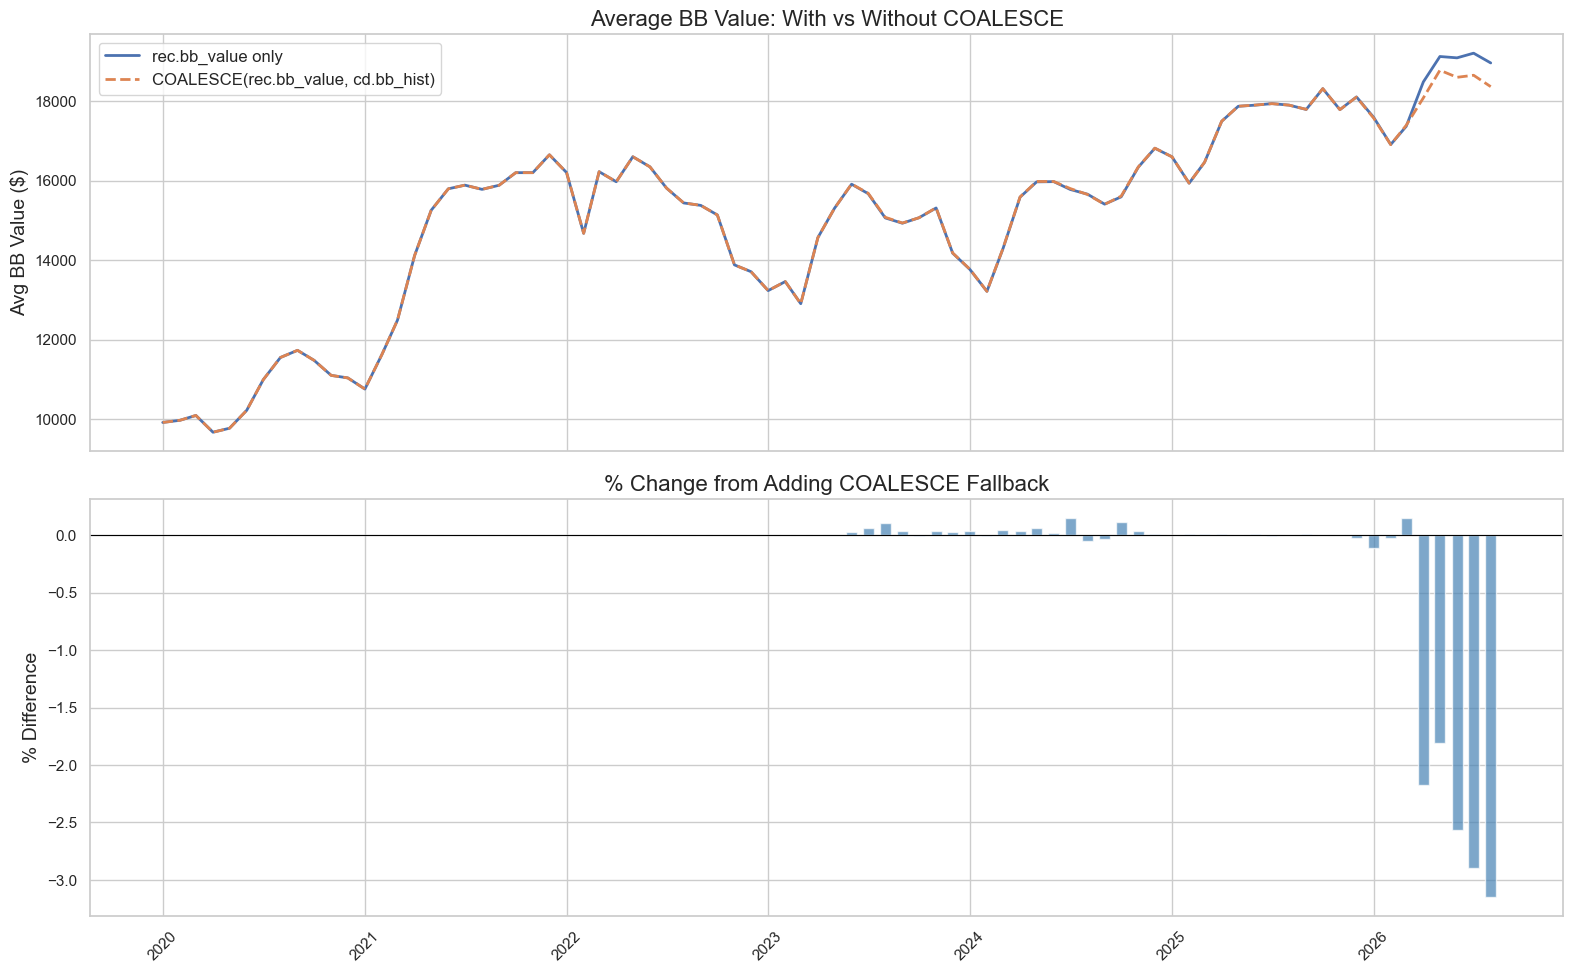


Extra rows gained from COALESCE (avg per month): 408
Avg % difference: -0.15%
Max % difference: 3.15%


In [13]:
compare_query = """
SELECT DATE_TRUNC('month', rec.con_date)                                          AS month,
       AVG(rec.bb_value)                                                          AS avg_bb_only,
       AVG(COALESCE(rec.bb_value, cd.blackbook_history_adj_wholesale_amt))         AS avg_coalesced,
       COUNT(rec.bb_value)                                                        AS n_bb_only,
       COUNT(COALESCE(rec.bb_value, cd.blackbook_history_adj_wholesale_amt))       AS n_coalesced
FROM   sandbox.rds_rec_model_originations rec
       LEFT JOIN edwnpi.los_deal_current_fact cd
              ON rec.account_number = cd.account_number
WHERE  rec.con_date >= '2020-01-01'
  AND  (rec.bb_value > 0 OR cd.blackbook_history_adj_wholesale_amt > 0)
GROUP  BY DATE_TRUNC('month', rec.con_date)
ORDER  BY month
"""

cmp_df = run_sql(compare_query)
cmp_df['month'] = pd.to_datetime(cmp_df['month'])
cmp_df['pct_diff'] = 100.0 * (cmp_df['avg_coalesced'] - cmp_df['avg_bb_only']) / cmp_df['avg_bb_only']
cmp_df['extra_rows'] = cmp_df['n_coalesced'] - cmp_df['n_bb_only']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(cmp_df['month'], cmp_df['avg_bb_only'], label='rec.bb_value only', linewidth=2)
axes[0].plot(cmp_df['month'], cmp_df['avg_coalesced'], label='COALESCE(rec.bb_value, cd.bb_hist)', linewidth=2, linestyle='--')
axes[0].set_ylabel('Avg BB Value ($)')
axes[0].set_title('Average BB Value: With vs Without COALESCE')
axes[0].legend(fontsize=12)

axes[1].bar(cmp_df['month'], cmp_df['pct_diff'], width=20, alpha=0.7, color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('% Difference')
axes[1].set_title('% Change from Adding COALESCE Fallback')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nExtra rows gained from COALESCE (avg per month): {cmp_df['extra_rows'].mean():,.0f}")
print(f"Avg % difference: {cmp_df['pct_diff'].mean():.2f}%")
print(f"Max % difference: {cmp_df['pct_diff'].abs().max():.2f}%")

In [16]:
fallback_query = """
SELECT DATE_TRUNC('month', rec.con_date)                       AS month,
       AVG(rec.bb_value)                                       AS avg_bb_only,
       AVG(CASE WHEN rec.bb_value IS NULL OR rec.bb_value = 0
                THEN cd.blackbook_history_adj_wholesale_amt END) AS avg_fallback_only,
       COUNT(rec.bb_value)                                     AS n_has_bb,
       SUM(CASE WHEN (rec.bb_value IS NULL OR rec.bb_value = 0)
                 AND cd.blackbook_history_adj_wholesale_amt > 0
                THEN 1 ELSE 0 END)                             AS n_fallback_only
FROM   sandbox.rds_rec_model_originations rec
       LEFT JOIN edwnpi.los_deal_current_fact cd
              ON rec.account_number = cd.account_number
WHERE  rec.con_date >= '2024-01-01'
GROUP  BY DATE_TRUNC('month', rec.con_date)
ORDER  BY month
"""

fb_df = run_sql(fallback_query)
fb_df['month'] = pd.to_datetime(fb_df['month'])
fb_df['pct_fallback'] = 100.0 * fb_df['n_fallback_only'] / (fb_df['n_has_bb'] + fb_df['n_fallback_only'])

display(fb_df.to_string(index=False))

'     month  avg_bb_only  avg_fallback_only  n_has_bb  n_fallback_only  pct_fallback\n2024-01-01 13768.169485            5603.40     16674               21      0.125786\n2024-02-01 13214.412552            5704.16     32122               43      0.133686\n2024-03-01 14286.160790            8436.73     32359               43      0.132708\n2024-04-01 15586.697208            5674.66     24175               19      0.078532\n2024-05-01 15972.030967            7702.36     22766               21      0.092158\n2024-06-01 15977.543201            5830.28     21377               43      0.200747\n2024-07-01 15779.516593           11729.36     19677               35      0.177557\n2024-08-01 15661.731484            1913.60     19038               17      0.089215\n2024-09-01 15410.368406            3710.75     17630               25      0.141603\n2024-10-01 15593.717434            5571.33     19829               18      0.090694\n2024-11-01 16341.738428            3902.50     20415            

In [14]:
import os

mmi_path = os.path.join(os.path.dirname(os.getcwd()), 'output', 'mmi_2019_seasonality.csv')
mmi_df = pd.read_csv(mmi_path, header=None, names=['month_str', 'mmi'])
mmi_df['month'] = pd.to_datetime(mmi_df['month_str'], format='%b-%y')
mmi_df = mmi_df[mmi_df['month'] >= '2020-01-01'].copy()

merged = pd.merge(bb_df, mmi_df[['month', 'mmi']], on='month', how='inner')
merged = merged.sort_values('month').reset_index(drop=True)

# Rescale avg bb_value so Jan-2020 anchors at 153.7 (the MMI starting value)
anchor_bb = merged.loc[merged['month'] == '2020-01-01', 'avg_bb_value'].values[0]
merged['bb_rescaled'] = 153.7 * (merged['avg_bb_value'] / anchor_bb)

print(f'Merged rows: {len(merged)}')
print(f'Anchor avg bb_value (Jan-2020): {anchor_bb:,.0f}')
display(merged.head(12))

Merged rows: 77
Anchor avg bb_value (Jan-2020): 9,911


,month,avg_bb_value,mmi,bb_rescaled
0,2020-01-01,9910.631992,153.7,153.700000
1,2020-02-01,9964.462445,156.2,154.534835
2,2020-03-01,10087.232352,152.7,156.438824
3,2020-04-01,9664.408685,135.7,149.881422
4,2020-05-01,9765.725572,149.0,151.452705
5,2020-06-01,10215.755149,163.4,158.432032
6,2020-07-01,10987.711327,173.2,170.403990
7,2020-08-01,11546.710461,180.9,179.073282
8,2020-09-01,11727.672447,176.7,181.879749
9,2020-10-01,11475.548684,178.8,177.969663


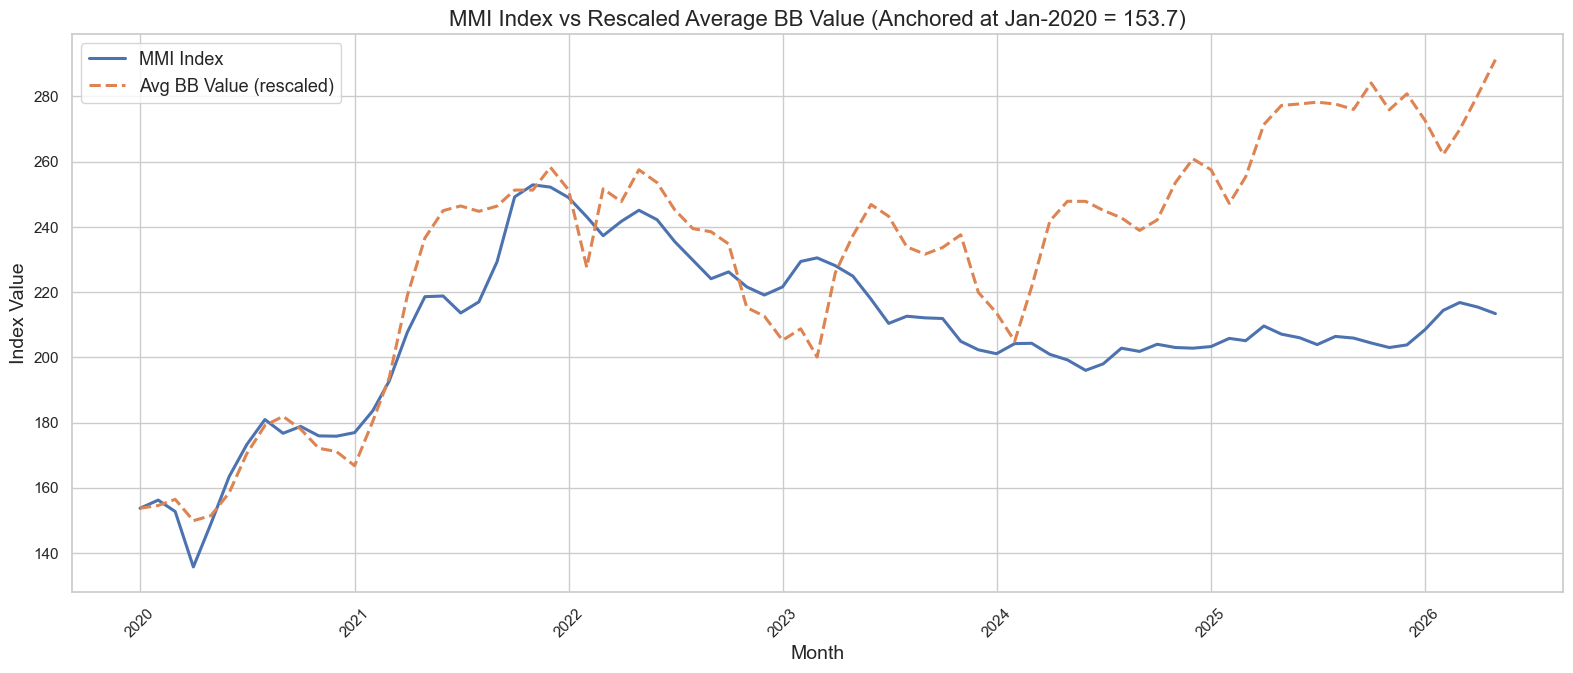

In [15]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(merged['month'], merged['mmi'], label='MMI Index', linewidth=2.2)
ax.plot(merged['month'], merged['bb_rescaled'], label='Avg BB Value (rescaled)', linewidth=2.2, linestyle='--')

ax.set_title('MMI Index vs Rescaled Average BB Value (Anchored at Jan-2020 = 153.7)')
ax.set_xlabel('Month')
ax.set_ylabel('Index Value')
ax.legend(fontsize=13)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()